In [98]:
import time

t0 = time.time()
print("Importing numpy/pandas...")
import os
import numpy as np
import pandas as pd
from itertools import product
print("Done basics in", time.time() - t0, "seconds")

print("Importing sklearn...")
from sklearn.model_selection import GroupKFold, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
print("Done sklearn in", time.time() - t0, "seconds")

print("Importing xgboost...")
from xgboost import XGBClassifier
print("Done xgboost in", time.time() - t0, "seconds")

print("Importing catboost...")
from catboost import CatBoostClassifier
print("Done catboost in", time.time() - t0, "seconds")

print("Importing tensorflow...")
from tensorflow import keras
from tensorflow.keras import layers
print("Done tensorflow in", time.time() - t0, "seconds")

print("Importing matplotlib...")
import matplotlib.pyplot as plt
print("Done matplotlib in", time.time() - t0, "seconds")

# Paths
DATA_DIR = "data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
print("All done in", time.time() - t0, "seconds")


Importing numpy/pandas...
Done basics in 0.0002498626708984375 seconds
Importing sklearn...
Done sklearn in 0.0005350112915039062 seconds
Importing xgboost...
Done xgboost in 0.0005841255187988281 seconds
Importing catboost...
Done catboost in 0.0006361007690429688 seconds
Importing tensorflow...
Done tensorflow in 0.0007219314575195312 seconds
Importing matplotlib...
Done matplotlib in 0.0007810592651367188 seconds
All done in 0.0011110305786132812 seconds


### Config and imports

In [99]:
# ========= 0. CONFIG & IMPORTS =========
import os
import numpy as np
import pandas as pd
from itertools import product

# Sklearn
from sklearn.model_selection import GroupKFold, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# CatBoost
from catboost import CatBoostClassifier

# Deep learning
from tensorflow import keras
from tensorflow.keras import layers

# Plots
import matplotlib.pyplot as plt

# --- Paths & global config ---
DATA_DIR = "data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

CHECKPOINTS = [6, 10, 15, 20]
MOM_WINDOW = 5
MOM_ALPHA = 2.0
TRAIN_LAST_SEASON = 2023  # temporal split: <= this is train, > this is test

USE_ELO = True  # toggle to compare with and without Elo
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### Data Prep – master checkpoints

In [100]:
# ========= 1. DATA PREP: BUILD MASTER CHECKPOINT DATASET =========

def load_raw():
    balls   = pd.read_csv(os.path.join(DATA_DIR, "cleaned_ball_by_ball_data.csv"))
    matches = pd.read_csv(os.path.join(DATA_DIR, "cleaned_match_data.csv"))
    return balls, matches

def build_matches_small(matches, balls):
    match_keep = [c for c in ["match_id","winner","toss_winner","venue","date","team1","team2","home_team"] 
                  if c in matches.columns]
    m = matches[match_keep].copy()
    if "date" in m.columns:
        m["season"] = pd.to_datetime(m["date"], errors="coerce").dt.year
    elif "date" in balls.columns:
        tmp = balls[["match_id","date"]].drop_duplicates("match_id")
        tmp["season"] = pd.to_datetime(tmp["date"], errors="coerce").dt.year
        m = m.merge(tmp[["match_id","season"]], on="match_id", how="left")
    else:
        m["season"] = np.nan
    return m

def build_first_innings_per_over(balls):
    inn1 = balls[balls["innings"] == 1].copy()
    po = (
        inn1.groupby(["match_id","over"])
            .agg(
                runs_in_over=("runs_total","sum"),
                wkts_in_over=("wicket","sum")
            ).reset_index()
            .sort_values(["match_id","over"])
    )
    po["cum_runs"] = po.groupby("match_id")["runs_in_over"].cumsum()
    po["cum_wkts"] = po.groupby("match_id")["wkts_in_over"].cumsum()
    return inn1, po

def build_features_at_checkpoints(po_df, checkpoints=CHECKPOINTS, mom_window=MOM_WINDOW, alpha=MOM_ALPHA):
    rows = []
    for mid, g in po_df.groupby("match_id"):
        rmap = dict(zip(g["over"], g["cum_runs"]))
        wmap = dict(zip(g["over"], g["cum_wkts"]))
        for cp in checkpoints:
            R_cp = rmap.get(cp, np.nan)
            W_cp = wmap.get(cp, np.nan)
            if pd.isna(R_cp) or pd.isna(W_cp):
                continue
            prev_over = max(cp - mom_window, 0)
            R_prev = rmap.get(prev_over, 0) if prev_over > 0 else 0
            W_prev = wmap.get(prev_over, 0) if prev_over > 0 else 0

            momentum_runs = R_cp - R_prev
            momentum_wkts = W_cp - W_prev
            denom = mom_window if cp >= mom_window else max(cp, 1)
            momentum_rr = momentum_runs / denom
            momentum_score = momentum_rr - alpha * momentum_wkts

            rows.append({
                "match_id": mid,
                "checkpoint": cp,
                "runs": int(R_cp),
                "wickets": int(W_cp),
                "overs_left": 20 - cp,
                "momentum_runs": momentum_runs,
                "momentum_wickets": momentum_wkts,
                "momentum_runrate": momentum_rr,
                "momentum_score": momentum_score
            })
    return pd.DataFrame(rows)

def build_master_checkpoints():
    balls, matches = load_raw()
    matches_small = build_matches_small(matches, balls)
    inn1, per_over = build_first_innings_per_over(balls)

    summary_df = build_features_at_checkpoints(per_over)

    # simple derived features
    summary_df["run_rate"]         = summary_df["runs"] / summary_df["checkpoint"]
    summary_df["runs_per_wicket"]  = summary_df["runs"] / (summary_df["wickets"] + 1)
    summary_df["pressure_index"]   = summary_df["runs_per_wicket"] / (summary_df["overs_left"] + 1)
    summary_df["checkpoint_ratio"] = summary_df["checkpoint"] / 20.0

    # true batting-first team
    bf_map = (
        inn1.sort_values(["match_id","over"])
            .groupby("match_id")
            .agg(batting_first_team=("team","first"))
            .reset_index()
    )

    summary_df = summary_df.merge(matches_small, on="match_id", how="left")
    summary_df = summary_df.merge(bf_map, on="match_id", how="left")

    # target: did batting-first team win?
    summary_df["target_batfirst"] = (summary_df["winner"] == summary_df["batting_first_team"]).astype("Int64")

    # clean season
    summary_df["season"] = pd.to_numeric(summary_df["season"], errors="coerce")
    before = len(summary_df)
    summary_df = summary_df.dropna(subset=["target_batfirst","season"]).copy()
    summary_df["season"] = summary_df["season"].astype(int)
    print(f"[MASTER] Dropped {before - len(summary_df)} rows due to missing target/season.")

    keep_cols = [
        "match_id","checkpoint","runs","wickets","overs_left",
        "run_rate","runs_per_wicket","pressure_index","checkpoint_ratio",
        "momentum_runs","momentum_wickets","momentum_runrate","momentum_score",
        "venue","season","toss_winner","winner","batting_first_team","team1","team2",
        "target_batfirst"
    ]
    keep_cols = [c for c in keep_cols if c in summary_df.columns]
    master_df = summary_df[keep_cols].reset_index(drop=True)

    path = os.path.join(PROCESSED_DIR, "bbl_master_checkpoints.csv")
    master_df.to_csv(path, index=False)
    print(f"Master dataset saved: {path} | shape={master_df.shape}")
    return master_df

master_df = build_master_checkpoints()


[MASTER] Dropped 0 rows due to missing target/season.
Master dataset saved: data/processed/bbl_master_checkpoints.csv | shape=(2404, 21)


### 3. Feature engineering: PAR, priors, Elo, interactions

In [101]:
# ========= 2. FEATURE ENGINEERING =========

def temporal_split(df, train_last_season=TRAIN_LAST_SEASON):
    train_df = df[df["season"] <= train_last_season].copy()
    test_df  = df[df["season"] >  train_last_season].copy()
    if test_df.empty:
        last_season = int(df["season"].max())
        print(f"No >{train_last_season} seasons. Using {last_season} as TEST.")
        test_df  = df[df["season"] == last_season].copy()
        train_df = df[df["season"] <  last_season].copy()
    print(f"TRAIN rows: {len(train_df)} | TEST rows: {len(test_df)} | TEST seasons: {sorted(test_df['season'].unique())}")
    return train_df, test_df

def add_par_resource(master_df):
    # recompute first-innings totals
    balls = pd.read_csv(os.path.join(DATA_DIR, "cleaned_ball_by_ball_data.csv"))
    inn1  = balls[balls["innings"] == 1].copy()
    per_over = (
        inn1.groupby(["match_id","over"])
            .agg(runs_in_over=("runs_total","sum"))
            .reset_index()
            .sort_values(["match_id","over"])
    )
    per_over["cum_runs"] = per_over.groupby("match_id")["runs_in_over"].cumsum()
    final_totals = (
        per_over.sort_values(["match_id","over"])
                .groupby("match_id")
                .agg(final_runs=("cum_runs","last"))
                .reset_index()
    )

    train_df, test_df = temporal_split(master_df)
    # merge final runs only to train
    train_df = train_df.merge(final_totals, on="match_id", how="left")
    train_df = train_df.dropna(subset=["final_runs"]).copy()
    train_df["remain_runs"] = (train_df["final_runs"] - train_df["runs"]).clip(lower=0)

    global_mean_final = float(train_df["final_runs"].mean())

    par_by_ckpt_wkts = (
        train_df.groupby(["checkpoint","wickets"], as_index=False)["runs"]
                .mean().rename(columns={"runs":"par_runs_cp"})
    )
    par_by_ckpt = (
        train_df.groupby("checkpoint", as_index=False)["runs"]
                .mean().rename(columns={"runs":"par_runs_ckpt_only"})
    )
    remain_by_ckpt_wkts = (
        train_df.groupby(["checkpoint","wickets"], as_index=False)["remain_runs"]
                .mean().rename(columns={"remain_runs":"exp_remain_runs"})
    )
    remain_by_ckpt = (
        train_df.groupby("checkpoint", as_index=False)["remain_runs"]
                .mean().rename(columns={"remain_runs":"exp_remain_ckpt_only"})
    )

    def apply_par_resource(frame):
        d = frame.copy()
        d = d.merge(par_by_ckpt_wkts, on=["checkpoint","wickets"], how="left")
        d = d.merge(remain_by_ckpt_wkts, on=["checkpoint","wickets"], how="left")
        d = d.merge(par_by_ckpt, on="checkpoint", how="left")
        d = d.merge(remain_by_ckpt, on="checkpoint", how="left")

        overall_par = float(train_df["runs"].mean())
        d["par_runs_cp_final"] = d["par_runs_cp"].fillna(d["par_runs_ckpt_only"]).fillna(overall_par)

        overall_rem = float(train_df["remain_runs"].mean())
        d["exp_remain_final"] = d["exp_remain_runs"].fillna(d["exp_remain_ckpt_only"]).fillna(overall_rem)

        d["par_gap_cp"]   = d["runs"] - d["par_runs_cp_final"]
        d["exp_final_20"] = d["runs"] + d["exp_remain_final"]
        d["resource_frac"] = d["exp_remain_final"] / max(global_mean_final, 1e-6)

        drop_cols = ["par_runs_cp","par_runs_ckpt_only","exp_remain_runs","exp_remain_ckpt_only"]
        d = d.drop(columns=[c for c in drop_cols if c in d.columns])
        return d

    train_aug = apply_par_resource(train_df.drop(columns=["final_runs","remain_runs"]))
    test_aug  = apply_par_resource(test_df)

    aug = pd.concat([train_aug, test_aug], axis=0, ignore_index=True)
    return aug

def add_venue_season_priors(df_with_par):
    train_df, test_df = temporal_split(df_with_par)

    venue_cp_runs = (
        train_df.dropna(subset=["venue"])
                .groupby(["venue","checkpoint"], as_index=False)["runs"]
                .mean().rename(columns={"runs":"venue_mean_runs_cp"})
    )
    venue_cp_wkts = (
        train_df.dropna(subset=["venue"])
                .groupby(["venue","checkpoint"], as_index=False)["wickets"]
                .mean().rename(columns={"wickets":"venue_mean_wkts_cp"})
    )
    season_cp_runs = (
        train_df.groupby(["season","checkpoint"], as_index=False)["runs"]
                .mean().rename(columns={"runs":"season_mean_runs_cp"})
    )
    season_cp_wkts = (
        train_df.groupby(["season","checkpoint"], as_index=False)["wickets"]
                .mean().rename(columns={"wickets":"season_mean_wkts_cp"})
    )

    has_exp_final = "exp_final_20" in train_df.columns
    if has_exp_final:
        venue_exp_final = (
            train_df.dropna(subset=["venue"])
                    .groupby("venue", as_index=False)["exp_final_20"]
                    .mean().rename(columns={"exp_final_20":"venue_mean_exp_final20"})
        )

    cp_runs_global = (
        train_df.groupby("checkpoint", as_index=False)["runs"]
                .mean().rename(columns={"runs":"cp_global_mean_runs"})
    )
    cp_wkts_global = (
        train_df.groupby("checkpoint", as_index=False)["wickets"]
                .mean().rename(columns={"wickets":"cp_global_mean_wkts"})
    )

    def add_priors(frame):
        d = frame.copy()
        d = d.merge(venue_cp_runs, on=["venue","checkpoint"], how="left")
        d = d.merge(venue_cp_wkts, on=["venue","checkpoint"], how="left")
        d = d.merge(season_cp_runs, on=["season","checkpoint"], how="left")
        d = d.merge(season_cp_wkts, on=["season","checkpoint"], how="left")
        d = d.merge(cp_runs_global, on="checkpoint", how="left")
        d = d.merge(cp_wkts_global, on="checkpoint", how="left")
        if has_exp_final:
            d = d.merge(venue_exp_final, on="venue", how="left")

        d["venue_mean_runs_cp"] = d["venue_mean_runs_cp"].fillna(d["cp_global_mean_runs"])
        d["venue_mean_wkts_cp"] = d["venue_mean_wkts_cp"].fillna(d["cp_global_mean_wkts"])
        d["season_mean_runs_cp"] = d["season_mean_runs_cp"].fillna(d["cp_global_mean_runs"])
        d["season_mean_wkts_cp"] = d["season_mean_wkts_cp"].fillna(d["cp_global_mean_wkts"])

        d = d.drop(columns=["cp_global_mean_runs","cp_global_mean_wkts"])
        return d

    train_aug = add_priors(train_df)
    test_aug  = add_priors(test_df)
    aug2 = pd.concat([train_aug, test_aug], axis=0, ignore_index=True)
    return aug2

def compute_elo_table():
    matches = pd.read_csv(os.path.join(DATA_DIR, "cleaned_match_data.csv")).dropna(subset=["team1","team2","winner"])
    matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
    matches = matches.sort_values("date").reset_index(drop=True)

    elo = {}
    base_rating = 1500
    K = 20

    def expected_win(rA, rB):
        return 1 / (1 + 10 ** ((rB - rA) / 400))

    records = []
    for _, row in matches.iterrows():
        t1, t2, w = row["team1"], row["team2"], row["winner"]
        r1 = elo.get(t1, base_rating)
        r2 = elo.get(t2, base_rating)
        e1 = expected_win(r1, r2)
        s1 = 1 if w == t1 else 0
        s2 = 1 - s1

        records.append({
            "match_id": row["match_id"],
            "team1": t1,
            "team2": t2,
            "elo_team1_pre": r1,
            "elo_team2_pre": r2,
            "elo_diff_pre": r1 - r2,
            "season": row.get("season", row["date"].year)
        })

        r1_new = r1 + K * (s1 - e1)
        r2_new = r2 + K * (s2 - (1 - e1))
        elo[t1] = r1_new
        elo[t2] = r2_new

    elo_df = pd.DataFrame(records)
    path = os.path.join(PROCESSED_DIR, "bbl_team_elo.csv")
    elo_df.to_csv(path, index=False)
    print(f"Elo table saved: {path} ({len(elo_df)} rows)")
    return elo_df

def merge_elo(df, elo_df):
    df = df.copy()

    # Avoid duplicate team1/team2 columns causing _x / _y suffixes
    for col in ["team1", "team2"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # Merge Elo info (includes team1, team2 from elo_df)
    df = df.merge(
        elo_df[["match_id", "team1", "team2", "elo_team1_pre", "elo_team2_pre", "elo_diff_pre"]],
        on="match_id",
        how="left"
    )

    # Compute batting/bowling Elo based on batting_first_team
    if "batting_first_team" in df.columns:
        df["elo_bat_first"] = np.where(
            df["batting_first_team"] == df["team1"],
            df["elo_team1_pre"],
            df["elo_team2_pre"],
        )
        df["elo_bowl_first"] = np.where(
            df["batting_first_team"] == df["team1"],
            df["elo_team2_pre"],
            df["elo_team1_pre"],
        )
    else:
        # Fallback: no batting_first_team info, just use team1/team2 Elo
        df["elo_bat_first"] = df["elo_team1_pre"]
        df["elo_bowl_first"] = df["elo_team2_pre"]

    # Final Elo difference feature
    df["elo_diff"] = df["elo_bat_first"] - df["elo_bowl_first"]
    return df


def build_modeling_dataset(use_elo=USE_ELO):
    df_par = add_par_resource(master_df)
    df_prior = add_venue_season_priors(df_par)

    if use_elo:
        elo_df = compute_elo_table()
        df_prior = merge_elo(df_prior, elo_df)

    # simple interaction features
    if {"runs","wickets"}.issubset(df_prior.columns):
        df_prior["runs_x_wickets"] = df_prior["runs"] * df_prior["wickets"]
    if {"runs_per_wicket","momentum_score"}.issubset(df_prior.columns):
        df_prior["r_pw_x_momentum"] = df_prior["runs_per_wicket"] * df_prior["momentum_score"]

    out_name = "bbl_model_dataset_with_elo.csv" if use_elo else "bbl_model_dataset_no_elo.csv"
    out_path = os.path.join(PROCESSED_DIR, out_name)
    df_prior.to_csv(out_path, index=False)
    print(f"Modeling dataset saved: {out_path} | shape={df_prior.shape}")
    return df_prior

df_model = build_modeling_dataset(use_elo=USE_ELO)


TRAIN rows: 2156 | TEST rows: 248 | TEST seasons: [np.int64(2024), np.int64(2025)]
TRAIN rows: 2156 | TEST rows: 248 | TEST seasons: [np.int64(2024), np.int64(2025)]
Elo table saved: data/processed/bbl_team_elo.csv (604 rows)
Modeling dataset saved: data/processed/bbl_model_dataset_with_elo.csv | shape=(2404, 39)


### 4. EDA (quick)

In [102]:
# ========= 3. EDA (LIGHT) =========

def simple_eda(df):
    print("Head:\n", df.head())
    print("\nTarget distribution (bat-first win = 1):")
    print(df["target_batfirst"].value_counts(normalize=True))
    print("\nBy checkpoint:")
    print(df.groupby("checkpoint")["target_batfirst"].mean())

simple_eda(df_model)


Head:
    match_id  checkpoint  runs  wickets  overs_left  run_rate  runs_per_wicket  \
0    524915           6    37        0          14  6.166667        37.000000   
1    524915          10    50        3          10  5.000000        12.500000   
2    524915          15   104        5           5  6.933333        17.333333   
3    524915          20   139        8           0  6.950000        15.444444   
4    524916           6    37        1          14  6.166667        18.500000   

   pressure_index  checkpoint_ratio  momentum_runs  ...            team1  \
0        2.466667              0.30             33  ...    Sydney Sixers   
1        1.136364              0.50             22  ...    Sydney Sixers   
2        2.888889              0.75             54  ...    Sydney Sixers   
3       15.444444              1.00             35  ...    Sydney Sixers   
4        1.233333              0.30             34  ...  Melbourne Stars   

            team2  elo_team1_pre elo_team2_pre  e

### 5. Train/Test split & feature matrices

In [103]:
# ========= 4. FEATURE MATRIX BUILDER =========

def build_feature_matrices(df):
    train_df, test_df = temporal_split(df)

    # numeric
    num_cols = [
        "runs","wickets","overs_left","run_rate","runs_per_wicket","pressure_index","checkpoint_ratio",
        "momentum_runs","momentum_wickets","momentum_runrate","momentum_score",
        "par_runs_cp_final","par_gap_cp","exp_remain_final","exp_final_20","resource_frac",
        "venue_mean_runs_cp","venue_mean_wkts_cp","season_mean_runs_cp","season_mean_wkts_cp",
        "runs_x_wickets","r_pw_x_momentum"
    ]
    # Elo numeric if present
    for c in ["elo_bat_first","elo_bowl_first","elo_diff"]:
        if c in df.columns:
            num_cols.append(c)

    # toss indicator
    if {"toss_winner","batting_first_team"}.issubset(df.columns):
        for d in (train_df, test_df):
            d["toss_win_batfirst"] = (d["toss_winner"] == d["batting_first_team"]).astype(int)
        num_cols.append("toss_win_batfirst")

    num_cols = [c for c in num_cols if c in train_df.columns]

    # categorical
    cat_cols = [c for c in ["venue","season","checkpoint"] if c in train_df.columns]

    X_train = train_df[num_cols + cat_cols].copy()
    y_train = train_df["target_batfirst"].astype(int).values
    X_test  = test_df[num_cols + cat_cols].copy()
    y_test  = test_df["target_batfirst"].astype(int).values

    return train_df, test_df, X_train, y_train, X_test, y_test, num_cols, cat_cols

train_df, test_df, X_train, y_train, X_test, y_test, num_cols, cat_cols = build_feature_matrices(df_model)


TRAIN rows: 2156 | TEST rows: 248 | TEST seasons: [np.int64(2024), np.int64(2025)]


In [104]:
train_df

,match_id,checkpoint,runs,wickets,overs_left,run_rate,runs_per_wicket,pressure_index,checkpoint_ratio,momentum_runs,...,team2,elo_team1_pre,elo_team2_pre,elo_diff_pre,elo_bat_first,elo_bowl_first,elo_diff,runs_x_wickets,r_pw_x_momentum,toss_win_batfirst
0,524915,6,37,0,14,6.166667,37.000000,2.466667,0.30,33,...,Brisbane Heat,1500.000000,1500.00000,0.000000,1500.000000,1500.00000,0.000000,0,244.200000,1
1,524915,10,50,3,10,5.000000,12.500000,1.136364,0.50,22,...,Brisbane Heat,1500.000000,1500.00000,0.000000,1500.000000,1500.00000,0.000000,150,-20.000000,1
2,524915,15,104,5,5,6.933333,17.333333,2.888889,0.75,54,...,Brisbane Heat,1500.000000,1500.00000,0.000000,1500.000000,1500.00000,0.000000,520,117.866667,1
3,524915,20,139,8,0,6.950000,15.444444,15.444444,1.00,35,...,Brisbane Heat,1500.000000,1500.00000,0.000000,1500.000000,1500.00000,0.000000,1112,15.444444,1
4,524916,6,37,1,14,6.166667,18.500000,1.233333,0.30,34,...,Sydney Thunder,1500.000000,1500.00000,0.000000,1500.000000,1500.00000,0.000000,37,88.800000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2151,1386112,20,151,7,0,7.550000,18.875000,18.875000,1.00,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1057,11.325000,1
2152,1386113,6,47,1,14,7.833333,23.500000,1.566667,0.30,43,...,Melbourne Stars,1456.402912,1431.06992,25.332993,1456.402912,1431.06992,25.332993,47,155.100000,0
2153,1386113,10,110,1,10,11.000000,55.000000,5.000000,0.50,67,...,Melbourne Stars,1456.402912,1431.06992,25.332993,1456.402912,1431.06992,25.332993,110,627.000000,0
2154,1386113,15,156,2,5,10.400000,52.000000,8.666667,0.75,46,...,Melbourne Stars,1456.402912,1431.06992,25.332993,1456.402912,1431.06992,25.332993,312,374.400000,0


In [139]:
train_df.shape

(2156, 40)

### 6. Shared evaluation & plotting

In [105]:
# ========= 5. SHARED EVAL & PLOTTING =========

def evaluate_binary_classifier(y_true, proba, threshold=0.5, model_name=""):
    preds = (proba >= threshold).astype(int)
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds)
    auc = roc_auc_score(y_true, proba)
    cm  = confusion_matrix(y_true, preds)
    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)
    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc,
        "Threshold": threshold
    }

def plot_metric_bar(results_df, metric="Accuracy"):
    plt.figure()
    plt.bar(results_df["Model"], results_df[metric])
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.title(f"Model comparison – {metric}")
    plt.tight_layout()
    plt.show()


### 7. Classical models (Logistic, SVM, RandomForest, XGBoost)

In [106]:
# ========= 6. CLASSICAL MODELS (with RF & XGB tuning) =========

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV, GroupKFold

def build_preprocessor(num_cols, cat_cols):
    """
    Preprocessor for *linear* models (Logistic, SVM):
    - Impute numeric with median
    - Scale numeric
    - Impute categorical
    - One-hot encode categorical
    """
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])
    
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])
    return pre


def build_tree_preprocessor(num_cols, cat_cols):
    """
    Preprocessor for tree models (RandomForest, XGBoost):
    - Impute numeric with median
    - Impute categorical + OrdinalEncode to integers
    - NO scaling
    """
    num_pipe = SimpleImputer(strategy="median")
    
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])
    
    pre_tree = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])
    return pre_tree


def run_classical_models(X_train, y_train, X_test, y_test, num_cols, cat_cols, groups):
    results = []

    # Preprocessors
    pre_lin  = build_preprocessor(num_cols, cat_cols)        # for Logistic, SVM, LASSO
    pre_tree = build_tree_preprocessor(num_cols, cat_cols)   # for RF, XGB

    # ========== Logistic Regression ==========
    log_pipe = Pipeline([
        ("pre", pre_lin),
        ("clf", LogisticRegression(max_iter=3000, solver="lbfgs"))
    ])
    log_param = {"clf__C": [0.1, 1.0, 10.0]}
    log_cv = GridSearchCV(log_pipe, log_param, cv=3, scoring="roc_auc", n_jobs=-1)
    log_cv.fit(X_train, y_train)
    proba_log = log_cv.predict_proba(X_test)[:, 1]
    results.append(evaluate_binary_classifier(y_test, proba_log, 0.5, "LogisticRegression"))

    # ========== SVM (RBF) ==========
    svm_pipe = Pipeline([
        ("pre", pre_lin),
        ("clf", SVC(probability=True))
    ])
    svm_param = {"clf__C": [0.5, 2.0], "clf__gamma": ["scale"]}
    svm_cv = GridSearchCV(svm_pipe, svm_param, cv=3, scoring="roc_auc", n_jobs=-1)
    svm_cv.fit(X_train, y_train)
    proba_svm = svm_cv.predict_proba(X_test)[:, 1]
    results.append(evaluate_binary_classifier(y_test, proba_svm, 0.5, "SVM_RBF"))

    # ========== LASSO Logistic Regression (L1) ==========
    lasso_pipe = Pipeline([
        ("pre", pre_lin),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="liblinear",   # required for L1
            max_iter=5000
        ))
    ])
    lasso_param = {"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]}
    lasso_cv = GridSearchCV(lasso_pipe, lasso_param, cv=3, scoring="roc_auc", n_jobs=-1)
    lasso_cv.fit(X_train, y_train)
    proba_lasso = lasso_cv.predict_proba(X_test)[:, 1]
    results.append(evaluate_binary_classifier(y_test, proba_lasso, 0.5, "LASSO_LogReg"))

    # ========= GroupKFold for tree models =========
    gkf = GroupKFold(n_splits=5)

    # ========== RandomForest ==========
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    rf_pipe = Pipeline([
        ("pre", pre_tree),
        ("clf", rf)
    ])
    rf_param = {
        "clf__n_estimators": [300, 400, 800],
        "clf__max_depth": [None, 10, 15, 20, 25],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 3],
        "clf__max_features": ["sqrt"]
    }
    rf_cv = GridSearchCV(
        rf_pipe,
        rf_param,
        cv=gkf.split(X_train, y_train, groups),
        scoring="roc_auc",
        n_jobs=-1
    )
    rf_cv.fit(X_train, y_train)
    print("Best RF params:", rf_cv.best_params_)
    proba_rf = rf_cv.predict_proba(X_test)[:, 1]
    results.append(evaluate_binary_classifier(y_test, proba_rf, 0.5, "RandomForest"))

    # ========== XGBoost ==========
    xgb = XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=8
    )
    xgb_pipe = Pipeline([
        ("pre", pre_tree),
        ("clf", xgb)
    ])
    xgb_param = {
        "clf__n_estimators": [500, 800],
        "clf__max_depth": [5, 7],
        "clf__learning_rate": [0.03, 0.05, 0.003, 0.0003],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__min_child_weight": [1, 3],
    }
    xgb_cv = GridSearchCV(
        xgb_pipe,
        xgb_param,
        cv=gkf.split(X_train, y_train, groups),
        scoring="roc_auc",
        n_jobs=-1
    )
    xgb_cv.fit(X_train, y_train)
    print("Best XGB params:", xgb_cv.best_params_)
    proba_xgb = xgb_cv.predict_proba(X_test)[:, 1]
    results.append(evaluate_binary_classifier(y_test, proba_xgb, 0.5, "XGBoost"))

    return results



# run
groups = train_df["match_id"].values  # group = match, same logic as CatBoost
classical_results = run_classical_models(
    X_train, y_train, X_test, y_test, num_cols, cat_cols, groups
)




=== LogisticRegression ===
Accuracy: 0.641 | F1: 0.539 | AUC: 0.632
Confusion matrix [[TN FP],[FN TP]]:
 [[107  46]
 [ 43  52]]

=== SVM_RBF ===
Accuracy: 0.601 | F1: 0.487 | AUC: 0.598
Confusion matrix [[TN FP],[FN TP]]:
 [[102  51]
 [ 48  47]]

=== LASSO_LogReg ===
Accuracy: 0.577 | F1: 0.472 | AUC: 0.607
Confusion matrix [[TN FP],[FN TP]]:
 [[96 57]
 [48 47]]
Best RF params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 800}

=== RandomForest ===
Accuracy: 0.593 | F1: 0.482 | AUC: 0.607
Confusion matrix [[TN FP],[FN TP]]:
 [[100  53]
 [ 48  47]]
Best XGB params: {'clf__colsample_bytree': 0.6, 'clf__learning_rate': 0.0003, 'clf__max_depth': 5, 'clf__min_child_weight': 3, 'clf__n_estimators': 800, 'clf__subsample': 0.6}

=== XGBoost ===
Accuracy: 0.621 | F1: 0.427 | AUC: 0.619
Confusion matrix [[TN FP],[FN TP]]:
 [[119  34]
 [ 60  35]]


### 8. CatBoost with GroupKFold & threshold tuning

In [107]:
# ========= 7. CATBOOST WITH GROUPKFold =========

def run_catboost_with_gkf(train_df, test_df, num_cols, cat_cols):
    X_train = train_df[num_cols + cat_cols].copy()
    y_train = train_df["target_batfirst"].astype(int).values
    groups  = train_df["match_id"].values

    X_test  = test_df[num_cols + cat_cols].copy()
    y_test  = test_df["target_batfirst"].astype(int).values

    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

    # compact grid (so it doesn't kill your Mac)
    grid = {
        "depth": [11],
        "learning_rate": [0.02],
        "l2_leaf_reg": [1],
        "iterations": [680, 690],
        "bagging_temperature": [1],
    }
    param_list = list(product(
        grid["depth"],
        grid["learning_rate"],
        grid["l2_leaf_reg"],
        grid["iterations"],
        grid["bagging_temperature"]
    ))

    gkf = GroupKFold(n_splits=5)
    best_auc = -1.0
    best_params = None

    for (depth, lr, l2, iters, bagtemp) in param_list:
        fold_aucs = []
        for tr_idx, va_idx in gkf.split(X_train, y_train, groups):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]

            mdl = CatBoostClassifier(
                depth=depth,
                learning_rate=lr,
                l2_leaf_reg=l2,
                iterations=iters,
                bagging_temperature=bagtemp,
                loss_function="Logloss",
                eval_metric="AUC",
                random_state=RANDOM_STATE,
                verbose=False
            )
            cat_idx_tr = [X_tr.columns.get_loc(c) for c in cat_cols]
            mdl.fit(X_tr, y_tr, cat_features=cat_idx_tr)
            proba_va = mdl.predict_proba(X_va)[:, 1]
            fold_aucs.append(roc_auc_score(y_va, proba_va))
        mean_auc = float(np.mean(fold_aucs))
        print(f"[CatBoost depth={depth}, lr={lr}, l2={l2}, iters={iters}, bagT={bagtemp}] CV AUC={mean_auc:.3f}")
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_params = dict(depth=depth, learning_rate=lr, l2_leaf_reg=l2,
                               iterations=iters, bagging_temperature=bagtemp)

    print("Best CatBoost params:", best_params, "| CV AUC:", best_auc)

    # OOF for threshold tuning
    oof = np.zeros(len(X_train), dtype=float)
    for tr_idx, va_idx in gkf.split(X_train, y_train, groups):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr = y_train[tr_idx]
        mdl = CatBoostClassifier(
            **best_params,
            loss_function="Logloss",
            eval_metric="AUC",
            random_state=RANDOM_STATE,
            verbose=False
        )
        cat_idx_tr = [X_tr.columns.get_loc(c) for c in cat_cols]
        mdl.fit(X_tr, y_tr, cat_features=cat_idx_tr)
        oof[va_idx] = mdl.predict_proba(X_va)[:, 1]

    cand_t = np.linspace(0.30, 0.70, 41)
    accs   = [accuracy_score(y_train, (oof >= t).astype(int)) for t in cand_t]
    best_t = float(cand_t[int(np.argmax(accs))])
    print(f"CatBoost OOF best threshold: {best_t:.3f} | OOF ACC={max(accs):.3f}")

    # Final model
    final_cat = CatBoostClassifier(
        **best_params,
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=RANDOM_STATE,
        verbose=False
    )
    final_cat.fit(X_train, y_train, cat_features=cat_idx)
    proba_test = final_cat.predict_proba(X_test)[:, 1]
    result = evaluate_binary_classifier(y_test, proba_test, best_t, "CatBoost")

    # by-checkpoint (optional, for analysis)
    by_cp = []
    test_df_tmp = test_df.copy()
    test_df_tmp["proba"] = proba_test
    test_df_tmp["pred"]  = (proba_test >= best_t).astype(int)
    for cp, g in test_df_tmp.groupby("checkpoint"):
        by_cp.append({
            "checkpoint": int(cp),
            "n_test": len(g),
            "Accuracy": accuracy_score(g["target_batfirst"], g["pred"]),
            "F1": f1_score(g["target_batfirst"], g["pred"]),
            "AUC": roc_auc_score(g["target_batfirst"], g["proba"])
        })
    by_cp_df = pd.DataFrame(by_cp).sort_values("checkpoint")
    print("\nCatBoost – by checkpoint:\n", by_cp_df)

    return result

catboost_result = run_catboost_with_gkf(train_df, test_df, num_cols, cat_cols)  


[CatBoost depth=11, lr=0.02, l2=1, iters=680, bagT=1] CV AUC=0.703
[CatBoost depth=11, lr=0.02, l2=1, iters=690, bagT=1] CV AUC=0.702
Best CatBoost params: {'depth': 11, 'learning_rate': 0.02, 'l2_leaf_reg': 1, 'iterations': 680, 'bagging_temperature': 1} | CV AUC: 0.7025781092939075
CatBoost OOF best threshold: 0.650 | OOF ACC=0.650

=== CatBoost ===
Accuracy: 0.669 | F1: 0.481 | AUC: 0.644
Confusion matrix [[TN FP],[FN TP]]:
 [[128  25]
 [ 57  38]]

CatBoost – by checkpoint:
    checkpoint  n_test  Accuracy        F1       AUC
0           6      64  0.687500  0.473684  0.652083
1          10      63  0.698413  0.512821  0.630342
2          15      61  0.655738  0.487805  0.663288
3          20      60  0.633333  0.450000  0.634548


In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def prepare_nn_tabular_data(train_df, test_df, num_cols, cat_cols):
    """
    Returns:
      X_num_tr, X_num_te        (scaled numeric arrays, NaN-free)
      cat_tr_arrays, cat_te_arrays  (list of int arrays per categorical col)
      cat_cardinalities         (list of cardinalities per categorical col)
      y_train, y_test           (target arrays)
    """
    # 1) Numeric: impute + scale
    num_train = train_df[num_cols].astype(float)
    num_test  = test_df[num_cols].astype(float)

    imputer = SimpleImputer(strategy="median")
    num_train_imp = imputer.fit_transform(num_train)
    num_test_imp  = imputer.transform(num_test)

    scaler = StandardScaler()
    X_num_tr = scaler.fit_transform(num_train_imp)
    X_num_te = scaler.transform(num_test_imp)

    # 2) Categorical: integer-encode
    cat_tr_arrays = []
    cat_te_arrays = []
    cat_cardinalities = []

    for col in cat_cols:
        all_vals = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        uniques = all_vals.unique()
        mapping = {v: i + 1 for i, v in enumerate(uniques)}  # 0 reserved for unknown

        tr_encoded = train_df[col].astype(str).map(mapping).fillna(0).astype(int).values
        te_encoded = test_df[col].astype(str).map(mapping).fillna(0).astype(int).values

        cat_tr_arrays.append(tr_encoded)
        cat_te_arrays.append(te_encoded)
        cat_cardinalities.append(len(uniques) + 1)

    y_train = train_df["target_batfirst"].astype(int).values
    y_test  = test_df["target_batfirst"].astype(int).values

    return (
        X_num_tr, X_num_te,
        cat_tr_arrays, cat_te_arrays,
        cat_cardinalities,
        y_train, y_test
    )


In [109]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def transformer_block(x, num_heads, ff_dim, dropout_rate=0.1, name_prefix=""):
    # Multi-head self-attention
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=ff_dim,
        name=f"{name_prefix}_mha"
    )(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    # Feed-forward
    ffn = layers.Dense(ff_dim * 4, activation="relu")(out1)
    ffn = layers.Dense(ff_dim)(ffn)
    ffn = layers.Dropout(dropout_rate)(ffn)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)

    return out2


### 9. Deep Neural Network – optimised for your Mac

In [110]:
def run_advanced_neural_net(train_df, test_df, num_cols, cat_cols):
    # ===== 1) Prepare data =====
    (
        X_num_tr, X_num_te,
        cat_tr_arrays, cat_te_arrays,
        cat_cardinalities,
        y_train, y_test
    ) = prepare_nn_tabular_data(train_df, test_df, num_cols, cat_cols)

    n_samples = X_num_tr.shape[0]
    n_num = X_num_tr.shape[1]
    print(f"NN numeric features: {n_num}, samples: {n_samples}")
    print("Categorical cols:", cat_cols)
    print("Cat cardinalities:", cat_cardinalities)

    # Train/val split on indices so we can slice all arrays consistently
    indices = np.arange(n_samples)
    tr_idx, val_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_train
    )

    def split(arr):
        return arr[tr_idx], arr[val_idx]

    X_num_tr_split, X_num_val_split = split(X_num_tr)
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    cat_tr_split = []
    cat_val_split = []
    for arr in cat_tr_arrays:
        arr_tr, arr_val = split(arr)
        cat_tr_split.append(arr_tr)
        cat_val_split.append(arr_val)

    # ===== 2) Class weights (in case of imbalance) =====
    classes = np.unique(y_tr)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_tr
    )
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
    print("NN class weights:", class_weight_dict)

    # ===== 3) Build Keras model (embeddings + MLP) =====
    # Numeric input
    num_input = layers.Input(shape=(n_num,), name="num_input")

    # Categorical inputs & embeddings
    cat_inputs = []
    cat_embeds = []

    for col, card in zip(cat_cols, cat_cardinalities):
        inp = layers.Input(shape=(1,), dtype="int32", name=f"{col}_in")
        cat_inputs.append(inp)

        # heuristic for embedding dim
        emb_dim = min(16, int(np.ceil(card ** 0.5 * 1.5)))
        emb = layers.Embedding(
            input_dim=card + 1,
            output_dim=emb_dim,
            name=f"{col}_emb"
        )(inp)
        emb = layers.Reshape((emb_dim,))(emb)
        cat_embeds.append(emb)

    # Concatenate all
    x = layers.Concatenate(name="concat_features")([num_input] + cat_embeds)

    # Deep MLP
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(
        inputs=[num_input] + cat_inputs,
        outputs=output,
        name="tabular_nn_with_embeddings"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()

    # ===== 4) Prepare tensors for Keras =====
    # Train
    train_inputs = [X_num_tr_split] + [arr_tr.reshape(-1, 1) for arr_tr in cat_tr_split]
    val_inputs   = [X_num_val_split] + [arr_val.reshape(-1, 1) for arr_val in cat_val_split]

    # Test
    test_inputs = [X_num_te] + [arr_te.reshape(-1, 1) for arr_te in cat_te_arrays]

    # ===== 5) Callbacks =====
    es = keras.callbacks.EarlyStopping(
        patience=40,
        restore_best_weights=True,
        monitor="val_loss"
    )
    lr_sched = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=12,
        min_lr=1e-5,
        verbose=1
    )

    # ===== 6) Train (this is the part that can take longer) =====
    history = model.fit(
        train_inputs,
        y_tr,
        validation_data=(val_inputs, y_val),
        epochs=350,          # quite high; ES will cut off earlier
        batch_size=32,
        callbacks=[es, lr_sched],
        verbose=1,
        class_weight=class_weight_dict
    )

    # ===== 7) Threshold tuning on VAL =====
    proba_val = model.predict(val_inputs).ravel()
    cand_t = np.linspace(0.30, 0.70, 41)
    accs   = [accuracy_score(y_val, (proba_val >= t).astype(int)) for t in cand_t]
    best_t = float(cand_t[int(np.argmax(accs))])
    print(f"NN best threshold on VAL: {best_t:.3f} | VAL ACC={max(accs):.3f}")

    # ===== 8) Evaluate on TEST =====
    proba_test = model.predict(test_inputs).ravel()

    # Safety: if anything still went NaN, neutralise to 0.5
    if np.isnan(proba_test).any():
        print("⚠️ Warning: NaNs found in NN predictions, replacing with 0.5 for metrics.")
        proba_test = np.nan_to_num(proba_test, nan=0.5)

    nn_result = evaluate_binary_classifier(
        y_test,
        proba_test,
        best_t,
        f"AdvancedNeuralNet (t={best_t:.3f})"
    )
    return nn_result


In [111]:
nn_result = run_advanced_neural_net(train_df, test_df, num_cols, cat_cols)
print(nn_result)


NN numeric features: 26, samples: 2156
Categorical cols: ['venue', 'season', 'checkpoint']
Cat cardinalities: [23, 16, 5]
NN class weights: {0: 0.9740112994350283, 1: 1.027413587604291}


Model: "tabular_nn_with_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ venue_in            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ season_in           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ checkpoint_in       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ venue_emb           │ (None, 1, 8)      │        192 │ venue_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ season_emb          │ (None, 1, 6)      │        102 │ season_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ checkpoint_emb      │ (None, 1, 4)      │         24 │ checkpoint_in[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 8)         │          0 │ venue_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 6)         │          0 │ season_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 4)         │          0 │ checkpoint_emb[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 44)        │          0 │ num_input[0][0],  │
│ (Concatenate)       │                   │            │ reshape_8[0][0],  │
│                     │                   │            │ reshape_9[0][0],  │
│                     │                   │            │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │     11,520 │ concat_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_19[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     32,896 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 54,847 (214.25 KB)

 Trainable params: 53,951 (210.75 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6038 - loss: 0.8793 - val_accuracy: 0.6088 - val_loss: 0.6697 - learning_rate: 0.0010
Epoch 2/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6648 - loss: 0.7093 - val_accuracy: 0.6412 - val_loss: 0.6644 - learning_rate: 0.0010
Epoch 3/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6337 - loss: 0.7006 - val_accuracy: 0.6204 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 4/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6684 - loss: 0.6439 - val_accuracy: 0.6574 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 5/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6752 - loss: 0.6467 - val_accuracy: 0.6759 - val_loss: 0.6314 - learning_rate: 0.0010
Epoch 6/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6558 - loss: 0.6834 - val_accuracy: 0.6759 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 7/350
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6649 - loss: 0.6313 - val_acc

### 10. Final comparison


=== Model comparison ===
                         Model  Accuracy        F1       AUC  Threshold
5                     CatBoost  0.669355  0.481013  0.643619       0.65
0           LogisticRegression  0.641129  0.538860  0.632267       0.50
4                      XGBoost  0.620968  0.426829  0.619401       0.50
1                      SVM_RBF  0.600806  0.487047  0.598349       0.50
3                 RandomForest  0.592742  0.482051  0.606674       0.50
2                 LASSO_LogReg  0.576613  0.472362  0.607018       0.50
6  AdvancedNeuralNet (t=0.480)  0.572581  0.480392  0.519780       0.48


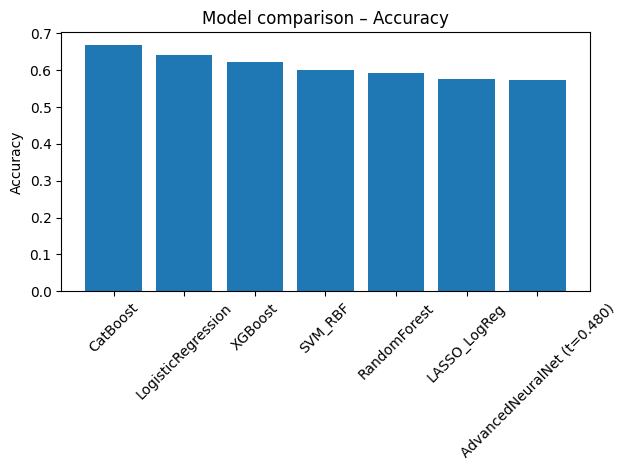

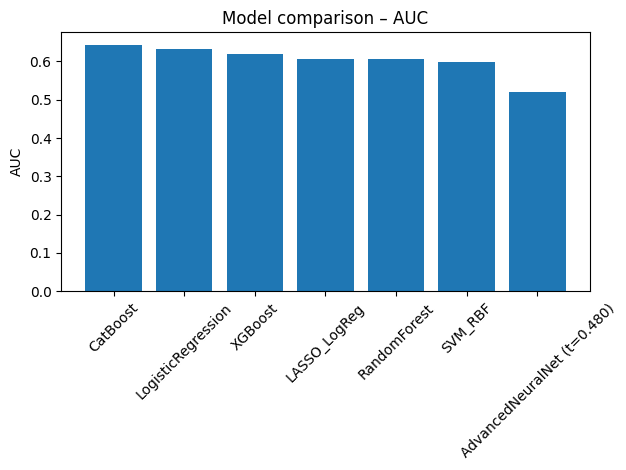

In [112]:
# ========= 9. FINAL COMPARISON =========

all_results = []
all_results.extend(classical_results)
all_results.append(catboost_result)
all_results.append(nn_result)

results_df = pd.DataFrame(all_results)
print("\n=== Model comparison ===")
print(results_df.sort_values("Accuracy", ascending=False))

plot_metric_bar(results_df.sort_values("Accuracy", ascending=False), metric="Accuracy")
plot_metric_bar(results_df.sort_values("AUC", ascending=False), metric="AUC")


# Visualization

In [118]:
# ========= 10. EXTRA VISUALISATIONS – Fit models for viz =========

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Reuse preprocessors from classical models
pre_lin  = build_preprocessor(num_cols, cat_cols)        # for Logistic
pre_tree = build_tree_preprocessor(num_cols, cat_cols)   # for XGBoost

# ---------- Logistic Regression (for ROC & comparison) ----------
logit_viz = Pipeline([
    ("pre", pre_lin),
    ("clf", LogisticRegression(max_iter=3000, solver="lbfgs"))
])
logit_viz.fit(X_train, y_train)
proba_logit_test = logit_viz.predict_proba(X_test)[:, 1]

# ---------- XGBoost (compact but strong config for viz) ----------
xgb_viz = Pipeline([
    ("pre", pre_tree),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_estimators=800,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=8
    ))
])
xgb_viz.fit(X_train, y_train)
proba_xgb_test = xgb_viz.predict_proba(X_test)[:, 1]

# ---------- CatBoost (reuse best params from earlier CV) ----------
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols]

cat_viz = CatBoostClassifier(
    depth=11,
    learning_rate=0.02,
    l2_leaf_reg=1,
    iterations=690,
    bagging_temperature=1,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=RANDOM_STATE,
    verbose=False
)
cat_viz.fit(X_train, y_train, cat_features=cat_features_idx)
proba_cat_test = cat_viz.predict_proba(X_test)[:, 1]

# Fix a threshold for CatBoost (from earlier tuning)
cat_best_threshold = 0.65
y_pred_cat = (proba_cat_test >= cat_best_threshold).astype(int)


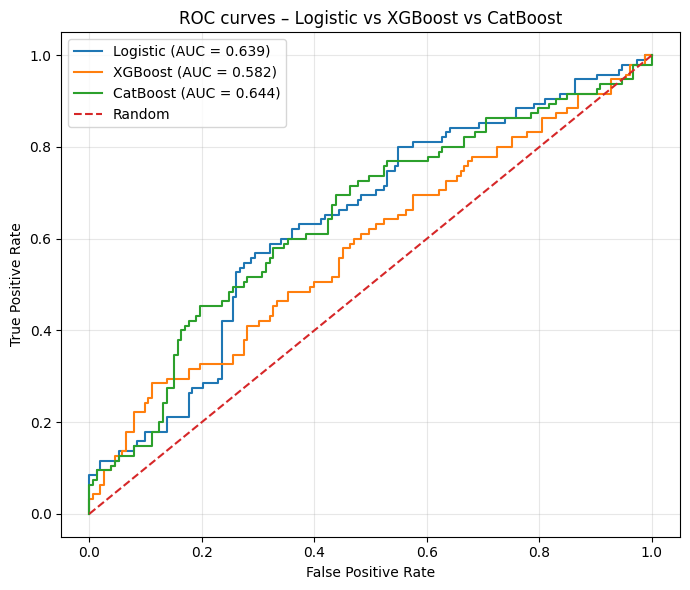

In [119]:
# ========= 10.1 ROC curves for top models =========

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, proba_logit_test)
auc_log = roc_auc_score(y_test, proba_logit_test)
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb_test)
auc_xgb = roc_auc_score(y_test, proba_xgb_test)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, proba_cat_test)
auc_cat = roc_auc_score(y_test, proba_cat_test)
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC = {auc_cat:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves – Logistic vs XGBoost vs CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


,feature,importance
27,season,19.585345
26,venue,19.247991
23,elo_bowl_first,8.047831
24,elo_diff,7.902443
22,elo_bat_first,7.643804
25,toss_win_batfirst,6.038806
14,exp_final_20,5.748148
28,checkpoint,5.028826
12,par_gap_cp,3.406830
4,runs_per_wicket,3.158162


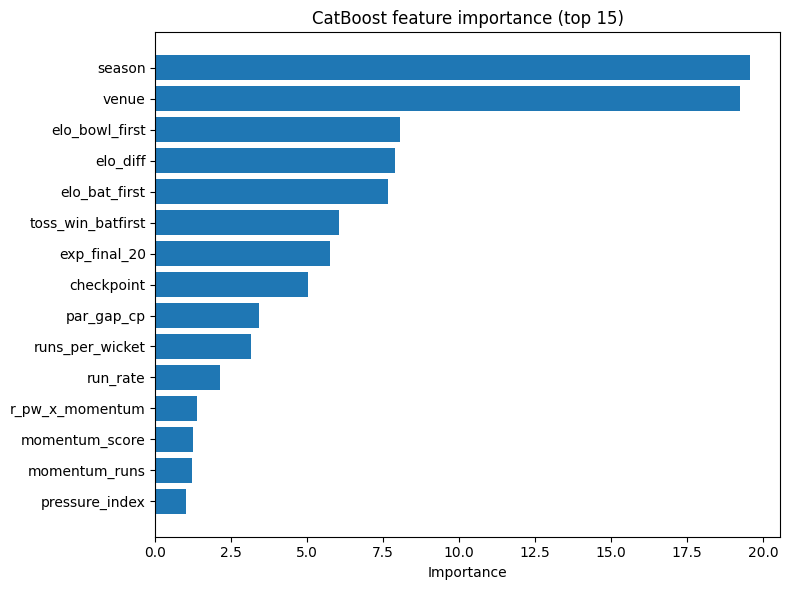

In [120]:
# ========= 10.2 CatBoost feature importance =========

import numpy as np
import pandas as pd

cb_importances = cat_viz.get_feature_importance()
feature_names = list(X_train.columns)

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cb_importances
}).sort_values("importance", ascending=False)

display(fi_df.head(20))

plt.figure(figsize=(8, 6))
top_n = 15
plt.barh(fi_df["feature"].head(top_n)[::-1], fi_df["importance"].head(top_n)[::-1])
plt.xlabel("Importance")
plt.title(f"CatBoost feature importance (top {top_n})")
plt.tight_layout()
plt.show()


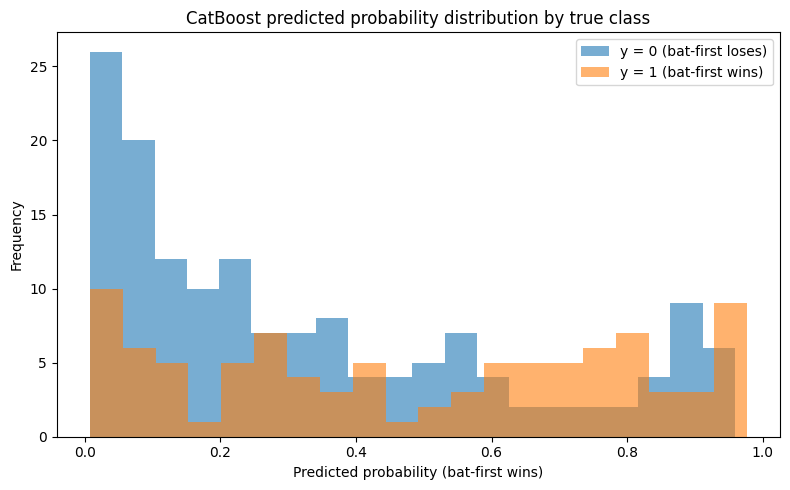

In [121]:
# ========= 10.3 CatBoost probability histogram =========

plt.figure(figsize=(8, 5))

mask_0 = (y_test == 0)
mask_1 = (y_test == 1)

plt.hist(proba_cat_test[mask_0], bins=20, alpha=0.6, label="y = 0 (bat-first loses)")
plt.hist(proba_cat_test[mask_1], bins=20, alpha=0.6, label="y = 1 (bat-first wins)")

plt.xlabel("Predicted probability (bat-first wins)")
plt.ylabel("Frequency")
plt.title("CatBoost predicted probability distribution by true class")
plt.legend()
plt.tight_layout()
plt.show()


,checkpoint,n_test,Accuracy,F1,AUC
0,6,64,0.687500,0.473684,0.657292
1,10,63,0.698413,0.512821,0.628205
2,15,61,0.655738,0.487805,0.662162
3,20,60,0.633333,0.450000,0.638073


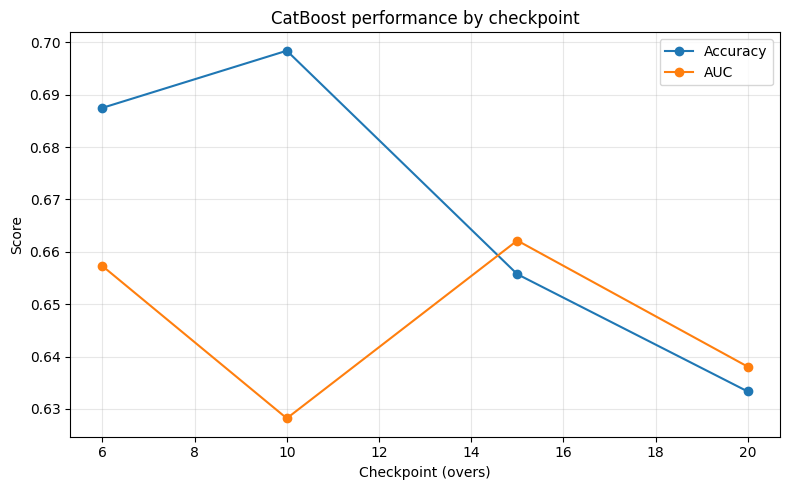

In [123]:
# ========= 10.5 CatBoost performance by checkpoint =========

from sklearn.metrics import accuracy_score, f1_score

test_with_pred = test_df.copy().reset_index(drop=True)
test_with_pred["proba_cat"] = proba_cat_test
test_with_pred["pred_cat"]  = (proba_cat_test >= cat_best_threshold).astype(int)

rows = []
for cp, g in test_with_pred.groupby("checkpoint"):
    rows.append({
        "checkpoint": int(cp),
        "n_test": len(g),
        "Accuracy": accuracy_score(g["target_batfirst"], g["pred_cat"]),
        "F1": f1_score(g["target_batfirst"], g["pred_cat"]),
        "AUC": roc_auc_score(g["target_batfirst"], g["proba_cat"]),
    })

by_cp_df = pd.DataFrame(rows).sort_values("checkpoint")
display(by_cp_df)

plt.figure(figsize=(8, 5))
plt.plot(by_cp_df["checkpoint"], by_cp_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(by_cp_df["checkpoint"], by_cp_df["AUC"], marker="o", label="AUC")
plt.xlabel("Checkpoint (overs)")
plt.ylabel("Score")
plt.title("CatBoost performance by checkpoint")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


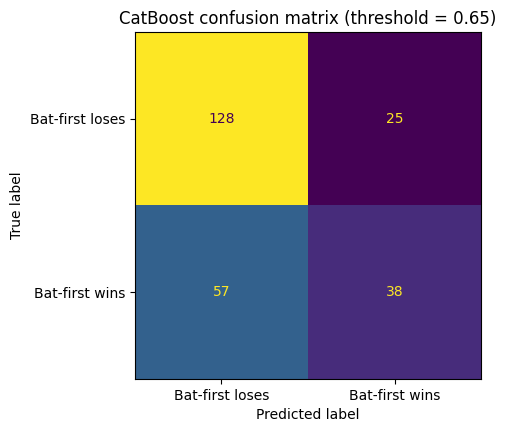

In [124]:
# ========= 10.6 CatBoost confusion matrix =========

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(cm, display_labels=["Bat-first loses", "Bat-first wins"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False)
plt.title(f"CatBoost confusion matrix (threshold = {cat_best_threshold:.2f})")
plt.tight_layout()
plt.show()


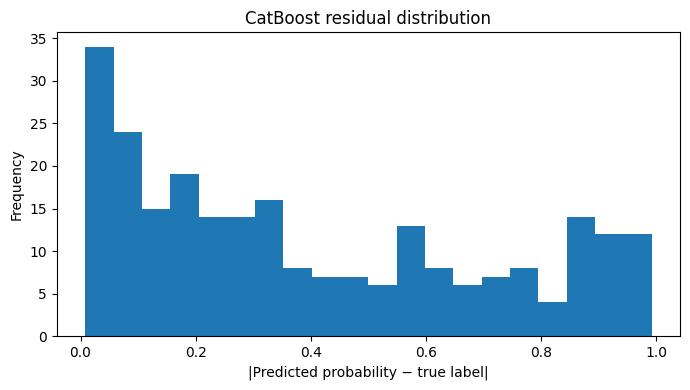

In [128]:
# ========= 10.9 Residual distribution (|p − y|) =========

residuals = np.abs(proba_cat_test - y_test)

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=20)
plt.xlabel("|Predicted probability − true label|")
plt.ylabel("Frequency")
plt.title("CatBoost residual distribution")
plt.tight_layout()
plt.show()


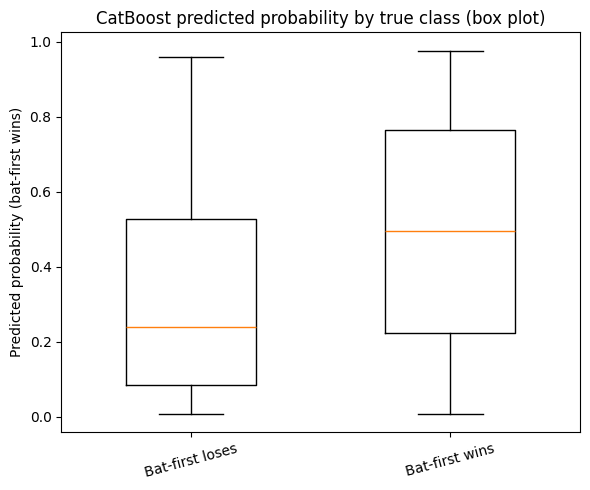

In [130]:
# ========= 10.11 Probability distribution by true class (box/violin style) =========

import pandas as pd

proba_df = pd.DataFrame({
    "y_true": y_test,
    "proba_cat": proba_cat_test
})
proba_df["y_label"] = proba_df["y_true"].map({0: "Bat-first loses", 1: "Bat-first wins"})

plt.figure(figsize=(6, 5))
positions = [0, 1]
data0 = proba_df[proba_df["y_true"] == 0]["proba_cat"]
data1 = proba_df[proba_df["y_true"] == 1]["proba_cat"]
plt.boxplot([data0, data1], positions=positions, widths=0.5)
plt.xticks(positions, ["Bat-first loses", "Bat-first wins"], rotation=15)
plt.ylabel("Predicted probability (bat-first wins)")
plt.title("CatBoost predicted probability by true class (box plot)")
plt.tight_layout()
plt.show()


/var/folders/b3/bn8rb2zx07s6g3tn45yxrtw40000gn/T/ipykernel_6918/2608768784.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_df


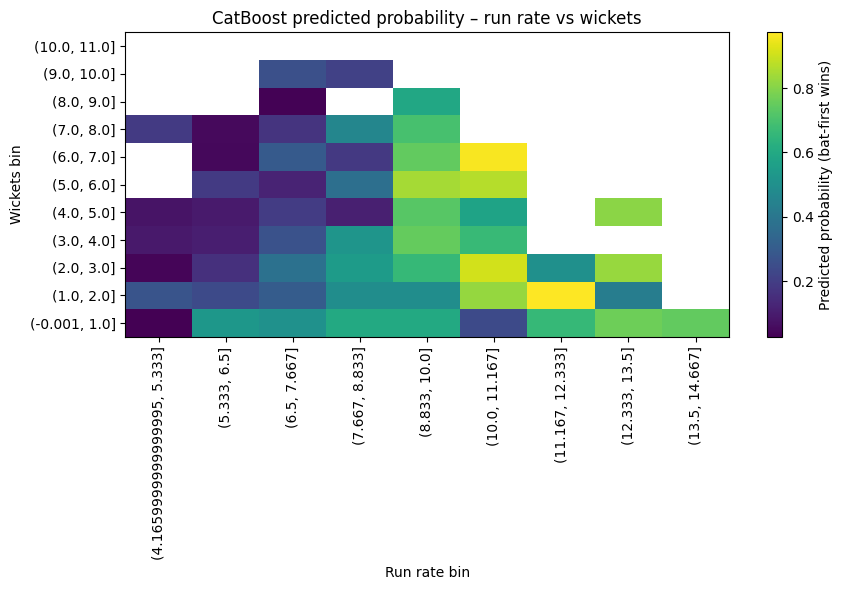

In [133]:
# ========= 10.14 Interaction heatmap (run_rate vs wickets vs probability) =========

heat_df = test_with_pred.copy()

runrate_col = "run_rate"
wickets_col = "wickets"

if runrate_col in heat_df.columns and wickets_col in heat_df.columns:
    # Bin run rate and wickets
    rr_bins = np.linspace(heat_df[runrate_col].min(), heat_df[runrate_col].max(), 10)
    w_bins  = np.arange(0, heat_df[wickets_col].max() + 2)

    heat_df["rr_bin"] = pd.cut(heat_df[runrate_col], bins=rr_bins, include_lowest=True)
    heat_df["w_bin"]  = pd.cut(heat_df[wickets_col], bins=w_bins, include_lowest=True)

    pivot = (
        heat_df
        .groupby(["w_bin", "rr_bin"])["proba_cat"]
        .mean()
        .unstack("rr_bin")
    )

    plt.figure(figsize=(9, 6))
    plt.imshow(pivot, aspect="auto", origin="lower")
    plt.colorbar(label="Predicted probability (bat-first wins)")
    plt.yticks(range(len(pivot.index)), [str(c) for c in pivot.index])
    plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=90)
    plt.ylabel("Wickets bin")
    plt.xlabel("Run rate bin")
    plt.title("CatBoost predicted probability – run rate vs wickets")
    plt.tight_layout()
    plt.show()
else:
    print(f"Columns {runrate_col} and/or {wickets_col} not found in test_df; adjust names if needed.")
